In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train= pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
test = test.drop('Id',axis=1)
train = train.drop('Id',axis=1)

In [127]:
train.shape

(1460, 80)

In [111]:
pd.describe_option('display.max_columns',None)
print(train.head())

   MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0          60       RL         65.0     8450   Pave   NaN      Reg   
1          20       RL         80.0     9600   Pave   NaN      Reg   
2          60       RL         68.0    11250   Pave   NaN      IR1   
3          70       RL         60.0     9550   Pave   NaN      IR1   
4          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
0         Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
1         Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
2         Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
3         Lvl    AllPub    Corner  ...        0    NaN   NaN         NaN   
4         Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  SalePrice  
0       0      2    2008        WD         Normal     20850

In [112]:
null_list = pd.DataFrame(train.isnull().sum().sort_values(ascending = False).reset_index(name='Count'))
print(null_list)

            index  Count
0          PoolQC   1453
1     MiscFeature   1406
2           Alley   1369
3           Fence   1179
4      MasVnrType    872
..            ...    ...
75         MoSold      0
76         YrSold      0
77       SaleType      0
78  SaleCondition      0
79      SalePrice      0

[80 rows x 2 columns]


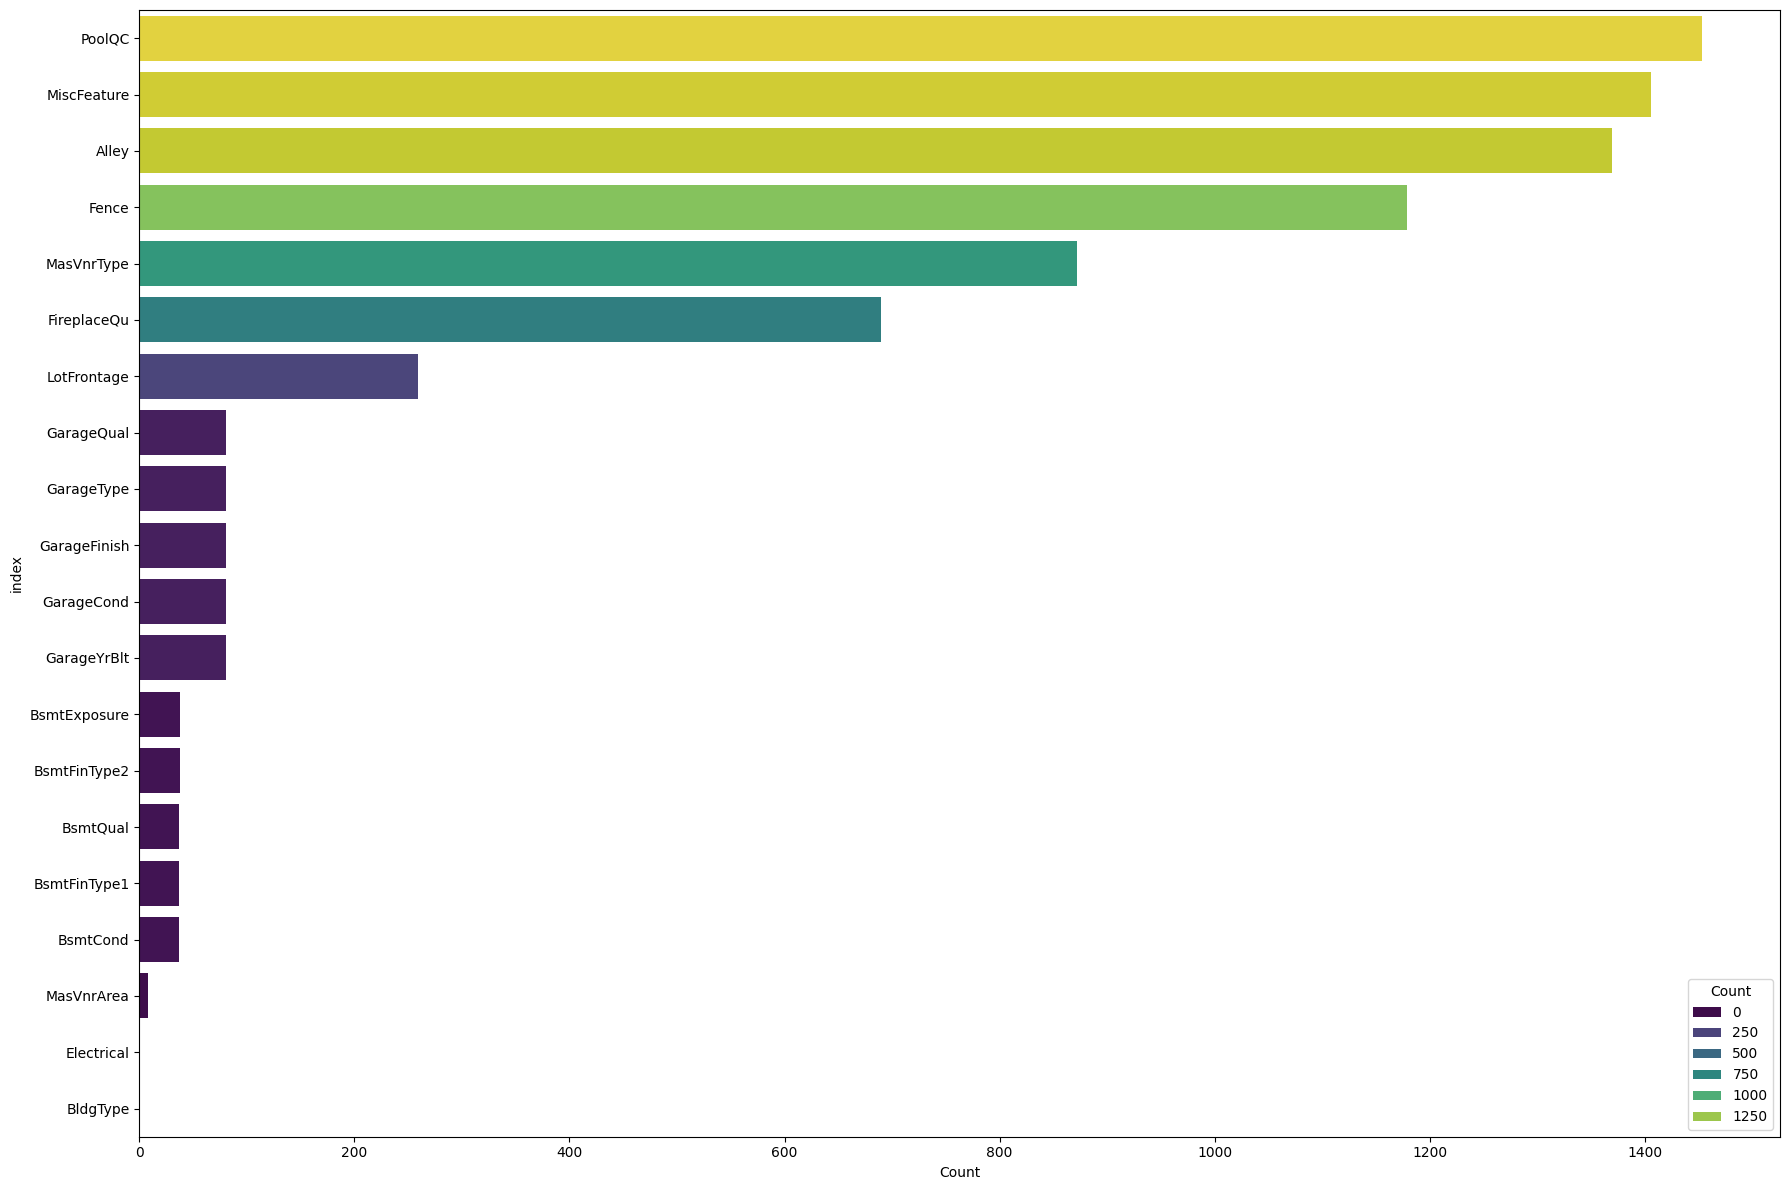

In [113]:
plt.figure(figsize = (18,12))
sns.barplot(data= null_list.head(20),x='Count',y='index',palette='viridis',hue='Count')
plt.tight_layout()
plt.show()

In [114]:
cat_features = train.select_dtypes(include=['object','category']).columns
num_features =  train.select_dtypes(include= ['int','float']).columns.drop('SalePrice')

In [115]:
print("Number of categorical features:",len(cat_features))
print("Number of numeric features:", len(num_features))

Number of categorical features: 43
Number of numeric features: 36


Target Describe count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Figure size 1500x1500 with 0 Axes>

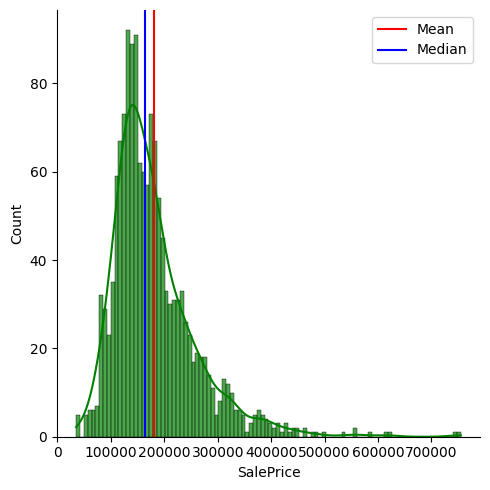

In [116]:
#Eexplore target distribution
print("Target Describe", train['SalePrice'].describe())
plt.figure(figsize =(15,15))
sns.displot(train['SalePrice'],color='g',bins=100,alpha = 0.7,kde =True)
plt.axvline(train['SalePrice'].mean(),color = 'red',label='Mean')
plt.axvline(train['SalePrice'].median(),color = 'blue',label='Median')
plt.tight_layout()
plt.legend()
plt.show()

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>],
       [<Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroo

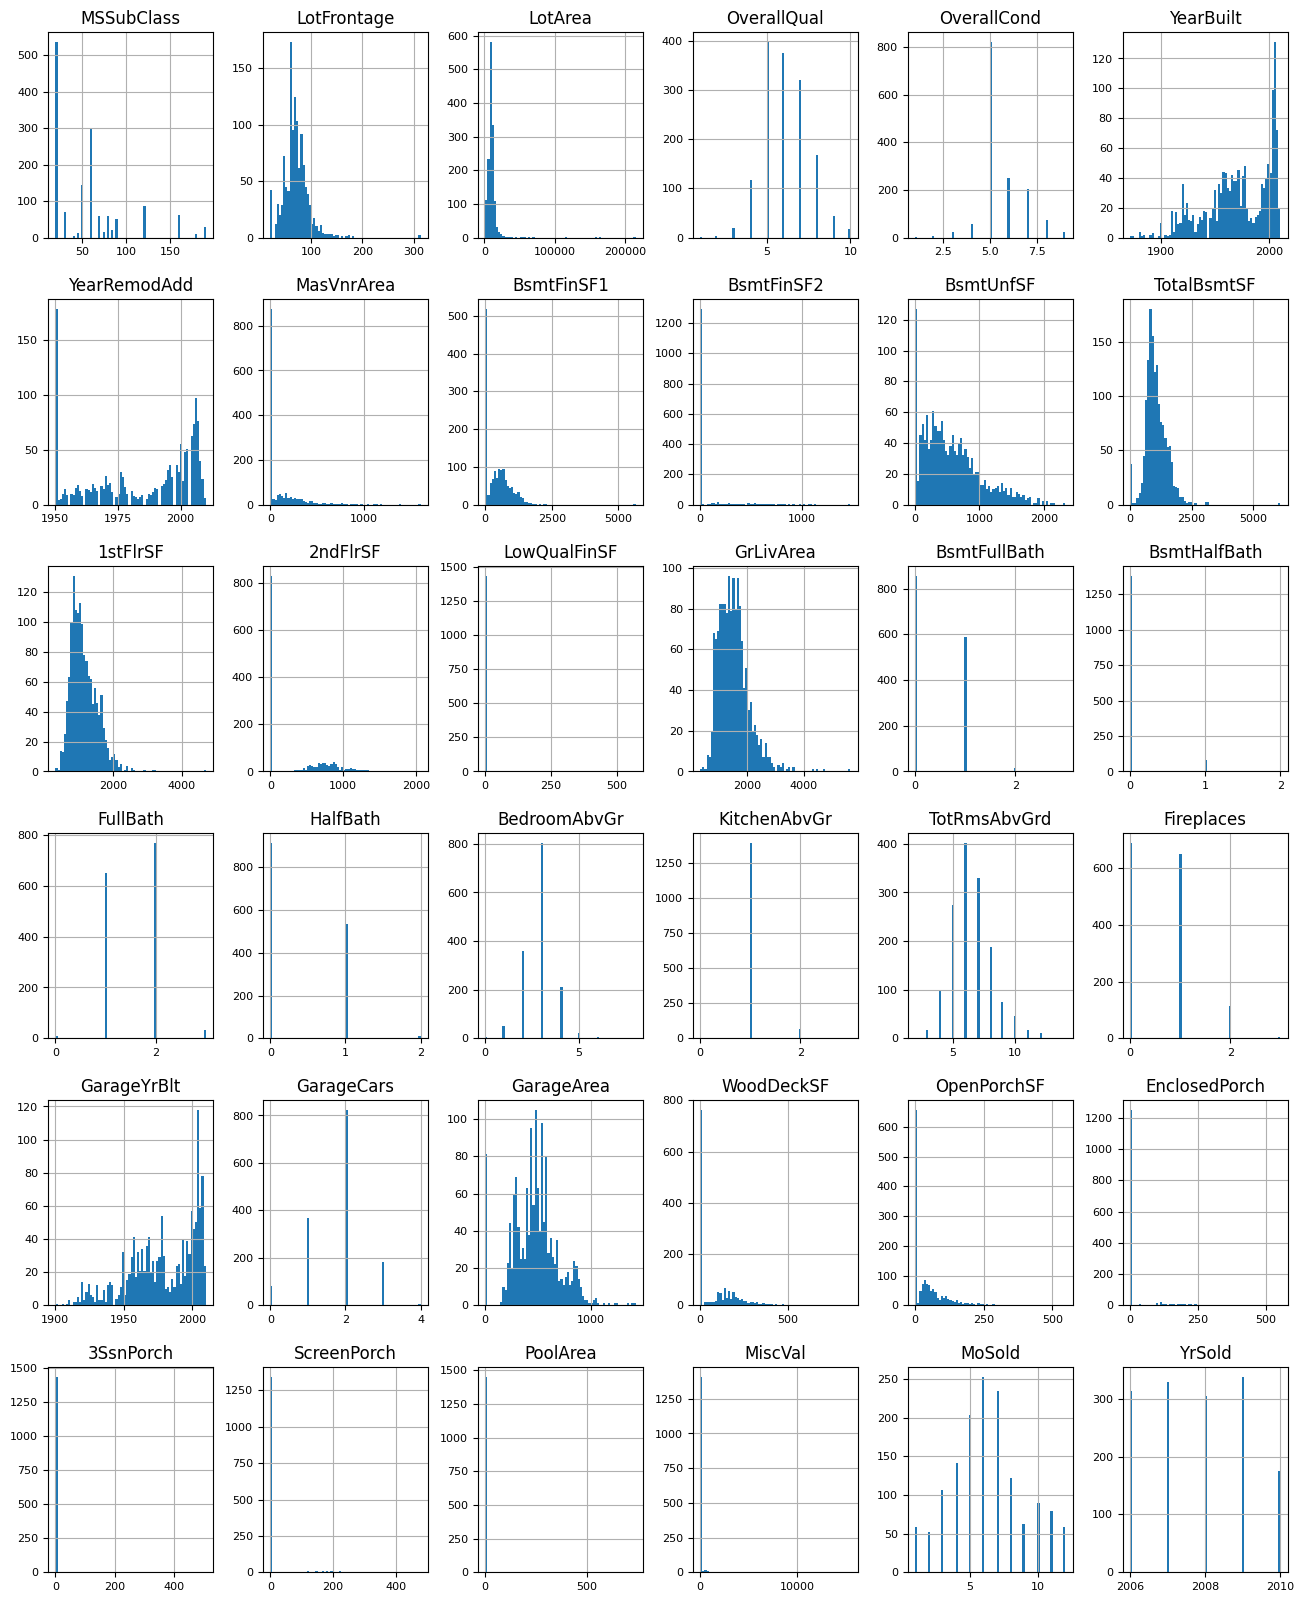

In [117]:
train[num_features].hist(bins=70,xlabelsize=8,ylabelsize=8,figsize=(16,20))

In [118]:
null_list = null_list[null_list['Count'] > 0]

In [119]:
null_list

,index,Count
0,PoolQC,1453
1,MiscFeature,1406
2,Alley,1369
3,Fence,1179
4,MasVnrType,872
5,FireplaceQu,690
6,LotFrontage,259
7,GarageQual,81
8,GarageType,81
9,GarageFinish,81


In [128]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [129]:
cat_pipeline = Pipeline(steps=[
    ('impiuter', SimpleImputer(strategy='constant',fill_value='Missing')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',StandardScaler())
])

In [130]:

preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_features),
    ('cat',cat_pipeline,cat_features)
])


In [131]:
from sklearn.model_selection import train_test_split
X = train.drop('SalePrice',axis=1)
y = train['SalePrice']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [132]:

X = train.drop('SalePrice',axis=1)
X_train

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20,RL,78.0,9317,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,3,2007,WD,Normal
1130,50,RL,65.0,7804,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,12,2009,WD,Normal
1294,20,RL,60.0,8172,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal
860,50,RL,55.0,7642,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,GdPrv,NaN,0,6,2007,WD,Normal


In [133]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [138]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [135]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth= None,
    min_samples_split=42,
    random_state= 42
)
rf.fit(X_train,y_train)


RandomForestRegressor(min_samples_split=42, random_state=42)

In [139]:
y_pred_rf= rf.predict(X_test)


<Figure size 1500x1500 with 0 Axes>

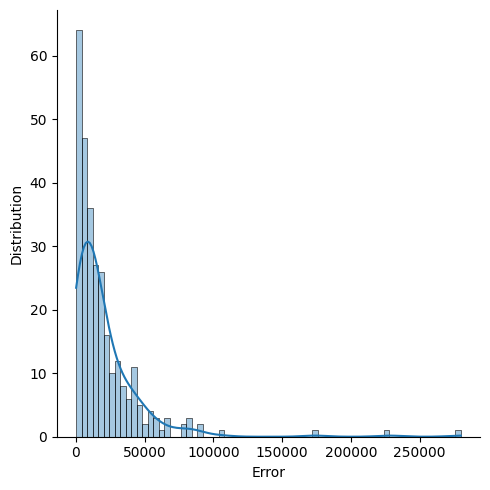

MAE:  20201.745174311527
MSE:  1222375742.646038
r2:  0.7446901603140444


In [143]:
def quick_report(y_pred,y_truth):
    error = abs(y_truth-y_pred)
    mae = mean_absolute_error(y_truth,y_pred)
    mse = mean_squared_error(y_truth,y_pred)
    r2 =r2_score(y_truth,y_pred)

    plt.figure(figsize=(15,15))
    sns.displot(data=error,kde=True,alpha=0.4,bins=70)
    plt.xlabel('Error')
    plt.ylabel('Distribution')
    plt.tight_layout()
    plt.show()

    print("MAE: ",mae)
    print("MSE: ",mse)
    print("r2: ", r2)
quick_report(y_test,y_pred_rf)


<Figure size 1500x1500 with 0 Axes>

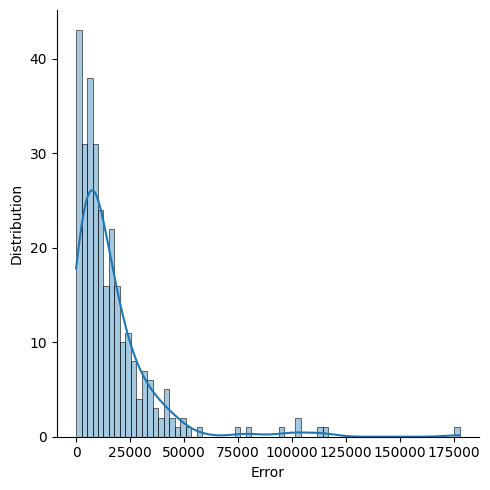

MAE:  15971.394791244296
MSE:  646182969.7199163
r2:  0.8970998500335147


In [146]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train,y_train)
y_pred_gb = gb.predict(X_test)
quick_report(y_test,y_pred_gb)

<Figure size 1500x1500 with 0 Axes>

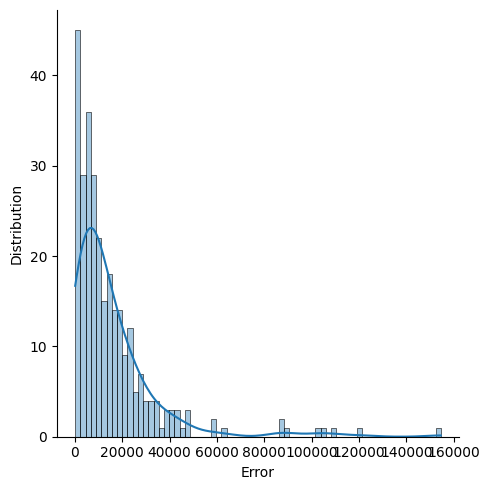

MAE:  15490.50390625
MSE:  624596096.0
r2:  0.9013846516609192


In [149]:
from xgboost import XGBRegressor

xgb= XGBRegressor(
    n_estimators =300,
    learning_rate=0.07,
    max_depth=4,
    subsample=0.8,
    colsample_bytree =0.8,
    random_state= 42
)
xgb.fit(X_train,y_train)
y_pred_xgb = xgb.predict(X_test)
quick_report(y_test,y_pred_xgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3233
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 193
[LightGBM] [Info] Start training from score 181441.541952


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<Figure size 1500x1500 with 0 Axes>

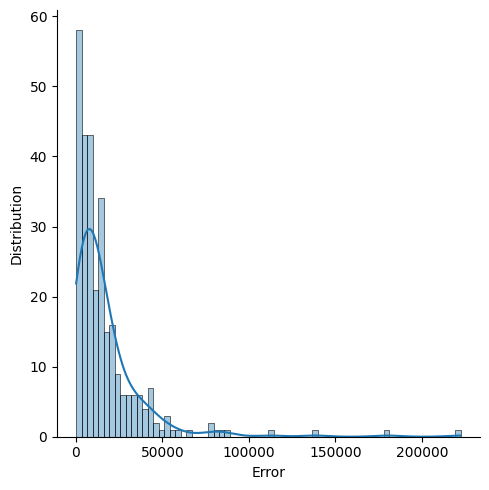

MAE:  16925.254701653048
MSE:  845812288.2104652
r2:  0.860551956599199


In [151]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,         # controls model complexity
    subsample=0.8,
    random_state=42
)
lgb.fit(X_train,y_train)
y_pred_lgb = lgb.predict(X_test)
quick_report(y_test,y_pred_lgb)

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

stack = StackingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb',  XGBRegressor(n_estimators=200, random_state=42)),
        ('lgbm', LGBMRegressor(n_estimators=200, random_state=42))
    ],
    final_estimator=RidgeCV()   # meta-model
)
stack.fit(X_train,y_train)
y_pred_stack = stack.predict(X_test)
quick_report(y_test,y_pred_stack)